Output from previsous run:

=== Per-threshold agreement percentages ===
Agreement ≥ 1 hypotheses: 1.71%
Agreement ≥ 2 hypotheses: 1.18%
Agreement ≥ 3 hypotheses: 0.91%
Agreement ≥ 4 hypotheses: 0.70%
Agreement ≥ 5 hypotheses: 0.50%

=== Per-hypothesis percentages ===
Hyp_1_blame: 1.12%
Hyp_2_blame: 1.00%
Hyp_3_blame: 0.73%
Hyp_4_blame: 1.25%
Hyp_5_blame: 0.88%


pct_threshold = {
    1: 1.71,
    2: 1.18,
    3: 0.91,
    4: 0.70,
    5: 0.50
}

pct_hyp = {
    "Hyp_1_blame": 1.12,
    "Hyp_2_blame": 1.00,
    "Hyp_3_blame": 0.73,
    "Hyp_4_blame": 1.25,
    "Hyp_5_blame": 0.88
}

total = 500500

plot_agreement_statistics_per_hyp(pct_threshold, pct_hyp, total)

In [1]:
import matplotlib.pyplot as plt
import os

In [ ]:
def plot_agreement_statistics_per_hyp(
    pct_threshold,
    threshold_f1,
    y_lim_pct=(0, 5),
    y_lim_f1=(0, 1)
):
    """
    Plot agreement threshold percentages with F1 scores
    on a secondary y-axis.

    Parameters
    ----------
    pct_threshold : dict
        Agreement threshold percentages.

    threshold_f1 : dict
        F1 scores corresponding to each agreement threshold.

    y_lim_pct : tuple
        Limits for percentage y-axis.

    y_lim_f1 : tuple
        Limits for F1 y-axis.
    """

    import matplotlib.pyplot as plt
    import os

    # ----------------------------------------------------------
    # Styling choices
    # ----------------------------------------------------------
    bar_color = "steelblue"
    line_color = "darkred"

    fig, ax1 = plt.subplots(figsize=(9, 5))

    threshold_keys = list(pct_threshold.keys())

    threshold_pct_values = [
        pct_threshold[k]
        for k in threshold_keys
    ]

    threshold_f1_values = [
        threshold_f1.get(k, None)
        for k in threshold_keys
    ]

    # ==========================================================
    # LEFT AXIS: Percentages
    # ==========================================================
    bars = ax1.bar(
        threshold_keys,
        threshold_pct_values,
        color=bar_color,
        alpha=0.8,
        label="% True labels"
    )

    ax1.set_xlabel(
        "Minimum hypothesis agreement",
        fontsize=12
    )

    ax1.set_ylabel(
        "Percentage of true labels in dataset (%)",
        color=bar_color,
        fontsize=12
    )

    ax1.tick_params(
        axis="y",
        labelcolor=bar_color
    )

    ax1.set_xticks(threshold_keys)

    ax1.set_ylim(*y_lim_pct)

    # ==========================================================
    # RIGHT AXIS: F1
    # ==========================================================
    ax2 = ax1.twinx()

    line = ax2.plot(
        threshold_keys,
        threshold_f1_values,
        color=line_color,
        marker="o",
        linewidth=2.5,
        markersize=8,
        label="F1 score"
    )

    ax2.set_ylabel(
        "F1 score",
        color=line_color,
        fontsize=12
    )

    ax2.tick_params(
        axis="y",
        labelcolor=line_color
    )

    ax2.set_ylim(*y_lim_f1)

    # ==========================================================
    # Title
    # ==========================================================
    plt.title(
        "Agreement Threshold Percentages and F1 Scores",
        fontsize=14,
        pad=15
    )

    # ==========================================================
    # Combined legend
    # ==========================================================
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper right",
        frameon=True
    )

    # ==========================================================
    # Grid
    # ==========================================================
    ax1.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(".", "per_threshold_bar_plot2.png"),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
def plot_agreement_statistics_per_hyp(
    pct_threshold,
    threshold_f1,
    y_lim_pct=(0, 5),
    y_lim_f1=(0, 1)
):
    """
    Create a publication-style dual-axis plot with:

    - Blue bars:
        Percentage of true labels in dataset (%)

    - Green line:
        F1 score

    Parameters
    ----------
    pct_threshold : dict
        Example:
        {
            1: 1.71,
            2: 1.18,
            3: 0.91,
            4: 0.70,
            5: 0.50
        }

    threshold_f1 : dict
        Example:
        {
            1: 0.55,
            2: 0.63,
            3: 0.71,
            4: 0.77,
            5: 0.81
        }

    y_lim_pct : tuple
        Example:
        (0, 5)

    y_lim_f1 : tuple
        Example:
        (0, 1)
    """

    import matplotlib.pyplot as plt
    import numpy as np
    import os

    # ----------------------------------------------------------
    # Data
    # ----------------------------------------------------------
    threshold_keys = list(pct_threshold.keys())

    pct_values = [
        pct_threshold[k]
        for k in threshold_keys
    ]

    f1_values = [
        threshold_f1[k]
        for k in threshold_keys
    ]

    x = np.arange(len(threshold_keys))

    # ----------------------------------------------------------
    # Figure
    # ----------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(11, 6))

    # ==========================================================
    # BAR PLOT (LEFT AXIS)
    # ==========================================================
    bar_color = "#126406"


    bars = ax1.bar(
        x,
        pct_values,
        width=0.48,
        color=bar_color,
        alpha=0.9,
        label="True Labels (%)"
    )

    # Left axis formatting
    ax1.set_ylabel(
        "True Labels (%)",
        fontsize=15,
        color=bar_color
    )

    ax1.tick_params(
        axis="y",
        labelsize=12,
        colors=bar_color
    )

    ax1.set_ylim(*y_lim_pct)

    # X-axis
    ax1.set_xticks(x)

    ax1.set_xticklabels(
        [f"{k}" for k in threshold_keys],
        fontsize=15
    )

    ax1.set_xlabel(
        "DIAL",
        fontsize=20
    )

    # Blue dashed horizontal grid
    ax1.grid(
        axis="y",
        linestyle="--",
        linewidth=1,
        alpha=0.35
    )

    # ==========================================================
    # F1 LINE (RIGHT AXIS)
    # ==========================================================
    ax2 = ax1.twinx()

    line_color = "#A83D0C"  # warm orange

    line = ax2.plot(
        x,
        f1_values,
        color=line_color,
        marker="o",
        markersize=5,
        linewidth=1,
        label="F1 Score"
    )

    # Right axis formatting
    ax2.set_ylabel(
        "F1 Score",
        fontsize=15,
        color=line_color
    )

    ax2.tick_params(
        axis="y",
        labelsize=12,
        colors=line_color
    )

    ax2.set_ylim(*y_lim_f1)

    # ==========================================================
    # TITLE
    # ==========================================================

    # ==========================================================
    # LEGENDS
    # ==========================================================
    # ==========================================================
    # COMBINED LEGEND (CENTER RIGHT)
    # ==========================================================

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    """ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="center right",
        fontsize=12,
        frameon=True,
        fancybox=True,
        borderpad=0.8
    )"""

    # ==========================================================
    # VALUE LABELS ABOVE BARS
    # ==========================================================
    for bar, value in zip(bars, pct_values):

        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=15,
            color=bar_color,
            weight="bold"
        )

    # ==========================================================
    # VALUE LABELS ABOVE LINE POINTS
    # ==========================================================
    for xi, value in zip(x, f1_values):

        ax2.text(
            xi,
            value + 0.005,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=15,
            color=line_color,
            weight="bold"
        )

    # ==========================================================
    # CLEAN SPINES
    # ==========================================================
    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    # ==========================================================
    # SAVE + SHOW
    # ==========================================================
    plt.tight_layout()

    plt.savefig(
        os.path.join(".", "agreement_thresholds_f1.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig("./f1_and_blame.png")
    plt.show()

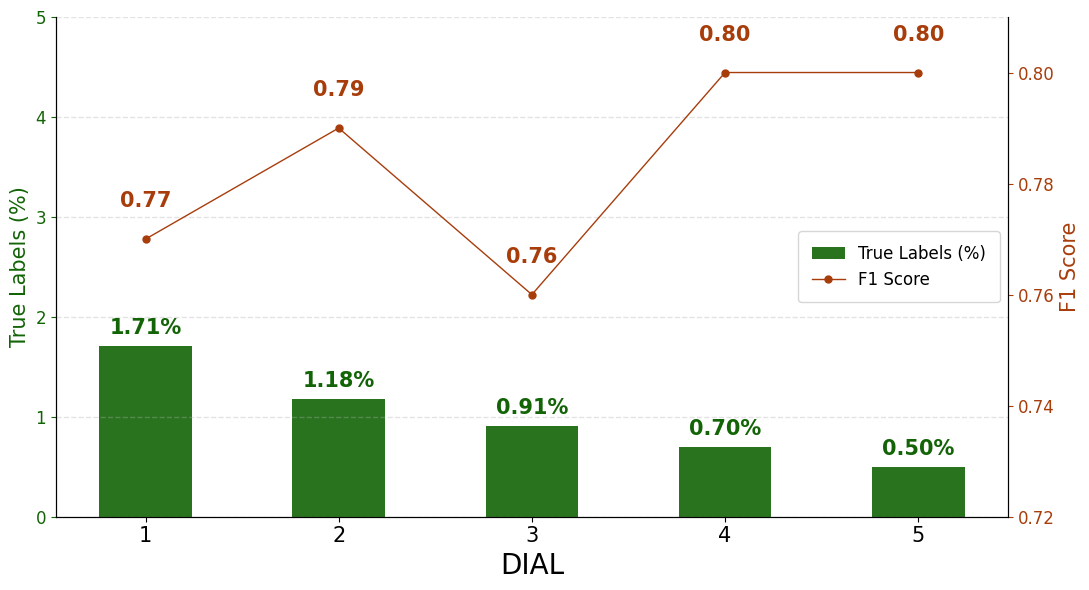

In [26]:
outdir = "."
pct_threshold = {
    1: 1.71,
    2: 1.18,
    3: 0.91,
    4: 0.70,
    5: 0.50
}

pct_hyp = {
    "Hyp_1_blame": 1.12,
    "Hyp_2_blame": 1.00,
    "Hyp_3_blame": 0.73,
    "Hyp_4_blame": 1.25,
    "Hyp_5_blame": 0.88
}

template_f1 = {
    1: 0.77,
    2: 0.79,
    3: 0.76,
    4: 0.80,
    5: 0.80
}

plot_agreement_statistics_per_hyp(
    pct_threshold,
    template_f1,
    y_lim_pct=(0, 5),
    y_lim_f1=(0.72, 0.81)
)